In [183]:
import numpy as np
import matplotlib.pyplot as plt

### Datos sinteticos

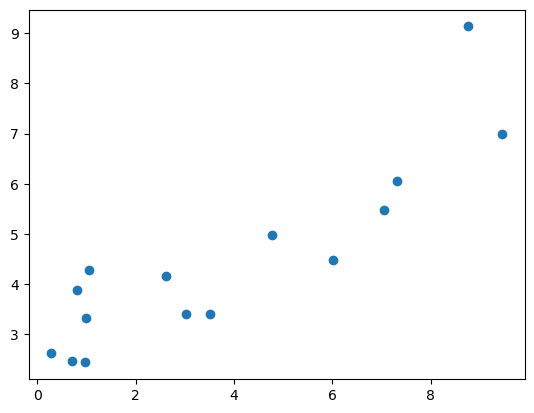

In [184]:
m = 15
X = 10 * np.random.rand(m, 1)
y = 0.5 * X + 2 + np.random.normal(0, 1, size=X.shape)
plt.scatter(X, y)
plt.show()

In [185]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((12, 1), (3, 1), (12, 1), (3, 1))

### Regresion lineal clasica

In [186]:
from sklearn.linear_model import LinearRegression

In [187]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

LinearRegression()

In [188]:
coefs = modelo_lr.coef_[0]
intercept = modelo_lr.intercept_[0]
print(f'y = {intercept:.3f} + {coefs[0]:.3f}x')

y = 2.751 + 0.415x


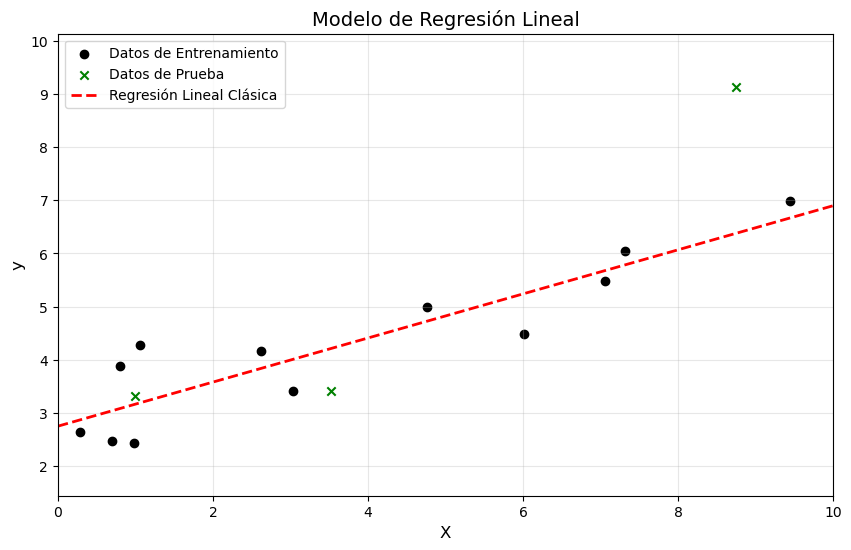

In [189]:
xx = np.linspace(0, 10, 2)
yy = modelo_lr.predict(xx.reshape(-1, 1))

plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train, c='black', label='Datos de Entrenamiento')
plt.scatter(X_test, y_test, c='green', marker='x', label='Datos de Prueba')

plt.plot(xx, yy, c='red', linestyle='--', linewidth=2, label='Regresión Lineal Clásica')

plt.title('Modelo de Regresión Lineal', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.xlim(0, 10)
plt.ylim(min(y.min(), y_test.min())-1, max(y.max(), y_test.max())+1)  # Límites dinámicos
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [190]:
from sklearn.metrics import mean_squared_error as mse
print('\nMétricas Reg Lineal:')
print(f'Error (train): {mse(y_train, modelo_lr.predict(X_train))}')
print(f'Error (test): {mse(y_test, modelo_lr.predict(X_test))}')


Métricas Reg Lineal:
Error (train): 0.33542837003026355
Error (test): 2.746551733280073


### Lasso

In [191]:
from sklearn.linear_model import Lasso

In [192]:
modelo_lasso = Lasso(alpha=0.3, random_state=42)
modelo_lasso.fit(X_train, y_train.ravel()) 

Lasso(alpha=0.3, random_state=42)

In [193]:
coefs_lasso = modelo_lasso.coef_
intercept_lasso = modelo_lasso.intercept_
print(f'\nRegresión Lasso:')
print(f'y = {intercept_lasso:.3f} + {coefs_lasso[0]:.3f}x')


Regresión Lasso:
y = 2.873 + 0.381x


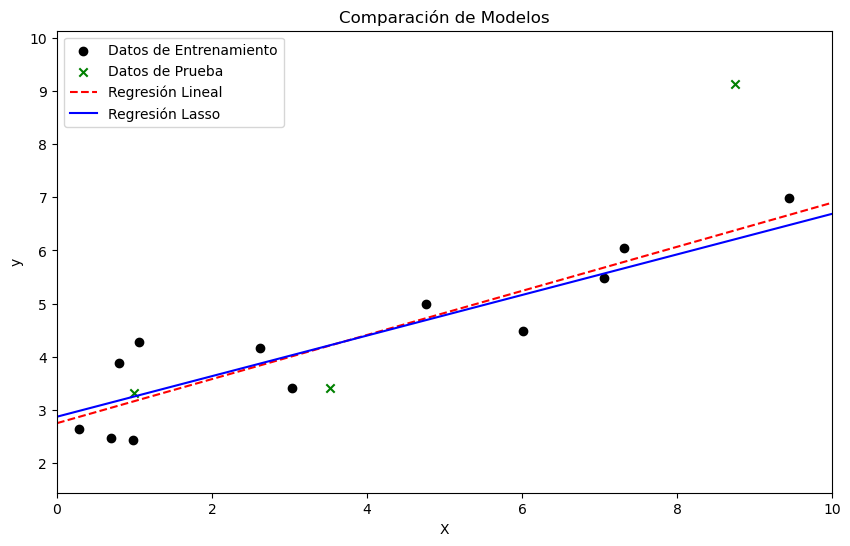

In [194]:
yy_lasso = modelo_lasso.predict(xx.reshape(-1, 1))

plt.figure(figsize=(10,6))
plt.scatter(X_train, y_train, c='black', label='Datos de Entrenamiento')
plt.scatter(X_test, y_test, c='green', marker='x', label='Datos de Prueba')
plt.plot(xx, yy, c='red', linestyle='--', label='Regresión Lineal')
plt.plot(xx, yy_lasso, c='blue', label='Regresión Lasso')
plt.title('Comparación de Modelos')
plt.xlabel('X')
plt.ylabel('y')
plt.xlim(0, 10)
plt.ylim(y.min()-1, y.max()+1)
plt.legend()
plt.show()

In [195]:
print('\nMétricas Lasso:')
print(f'Error (train): {mse(y_train, modelo_lasso.predict(X_train)):.3f}')
print(f'Error (test): {mse(y_test, modelo_lasso.predict(X_test)):.3f}')


Métricas Lasso:
Error (train): 0.345
Error (test): 3.060
